# Ноутбук 00 — Разведочный анализ данных (EDA)
**Раздел 2.2 ПЗ — Визуальный анализ данных**

Ни один файл из `data/raw/` не изменяется. Все артефакты сохраняются в:
- `reports/figures/` — рисунки (.png)
- `reports/tables/` — таблицы (.csv)

In [1]:
# ── Ячейка 0: Импорты и пути ────────────────────────────────────────────────
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.config import (
    DATA_RAW, FIGURES, TABLES,
    DATE_COL, STORE_COL, FAMILY_COL, TRAIN_CUTOFF
)
from src.io.preprocess import load_raw_files, fill_oil_gaps

FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.family": "DejaVu Sans",
})

print("Импорты выполнены.")

Импорты выполнены.


In [2]:
# ── Ячейка 1: Загрузка всех файлов датасета ─────────────────────────────────
# Функция load_raw_files() читает из DATA_RAW, файлы НЕ изменяются
data = load_raw_files()

for name, df in data.items():
    print(f"{name:15s}: {df.shape[0]:>10,} строк  |  {df.shape[1]} столбцов  |  ",
          f"пропуски: {df.isnull().mean().max()*100:.1f} % (max по столбцу)")

train          :  3,000,888 строк  |  6 столбцов  |   пропуски: 0.0 % (max по столбцу)
test           :     28,512 строк  |  5 столбцов  |   пропуски: 0.0 % (max по столбцу)
stores         :         54 строк  |  5 столбцов  |   пропуски: 0.0 % (max по столбцу)
oil            :      1,218 строк  |  2 столбцов  |   пропуски: 3.5 % (max по столбцу)
holidays       :        350 строк  |  6 столбцов  |   пропуски: 0.0 % (max по столбцу)
transactions   :     83,488 строк  |  3 столбцов  |   пропуски: 0.0 % (max по столбцу)


In [3]:
# ── Ячейка 2: Паспорт файлов → reports/tables/table_dataset_passport.csv ────
rows = []
for name, df in data.items():
    date_min = df[DATE_COL].min() if DATE_COL in df.columns else None
    date_max = df[DATE_COL].max() if DATE_COL in df.columns else None
    null_max_col = df.isnull().mean().idxmax()
    null_max_pct = df.isnull().mean().max() * 100
    rows.append({
        "Файл": f"{name}.csv",
        "Строк": df.shape[0],
        "Столбцов": df.shape[1],
        "Дата начала": date_min,
        "Дата конца": date_max,
        "Столбец с макс. пропусками": null_max_col,
        "Доля пропусков, %": round(null_max_pct, 2),
    })

passport = pd.DataFrame(rows)
passport.to_csv(TABLES / "table_dataset_passport.csv", index=False)
print("Таблица 2.1 — Паспорт файлов датасета")
display(passport)

Таблица 2.1 — Паспорт файлов датасета


,Файл,Строк,Столбцов,Дата начала,Дата конца,Столбец с макс. пропусками,"Доля пропусков, %"
0,train.csv,3000888,6,2013-01-01,2017-08-15,id,0.00
1,test.csv,28512,5,2017-08-16,2017-08-31,id,0.00
2,stores.csv,54,5,NaT,NaT,store_nbr,0.00
3,oil.csv,1218,2,2013-01-01,2017-08-31,dcoilwtico,3.53
4,holidays.csv,350,6,2012-03-02,2017-12-26,date,0.00
5,transactions.csv,83488,3,2013-01-01,2017-08-15,date,0.00


Доля нулевых продаж: 31.3 %
count    3000888.00
mean         357.78
std         1102.00
min            0.00
25%            0.00
50%           11.00
75%          195.85
max       124717.00
Name: sales, dtype: float64


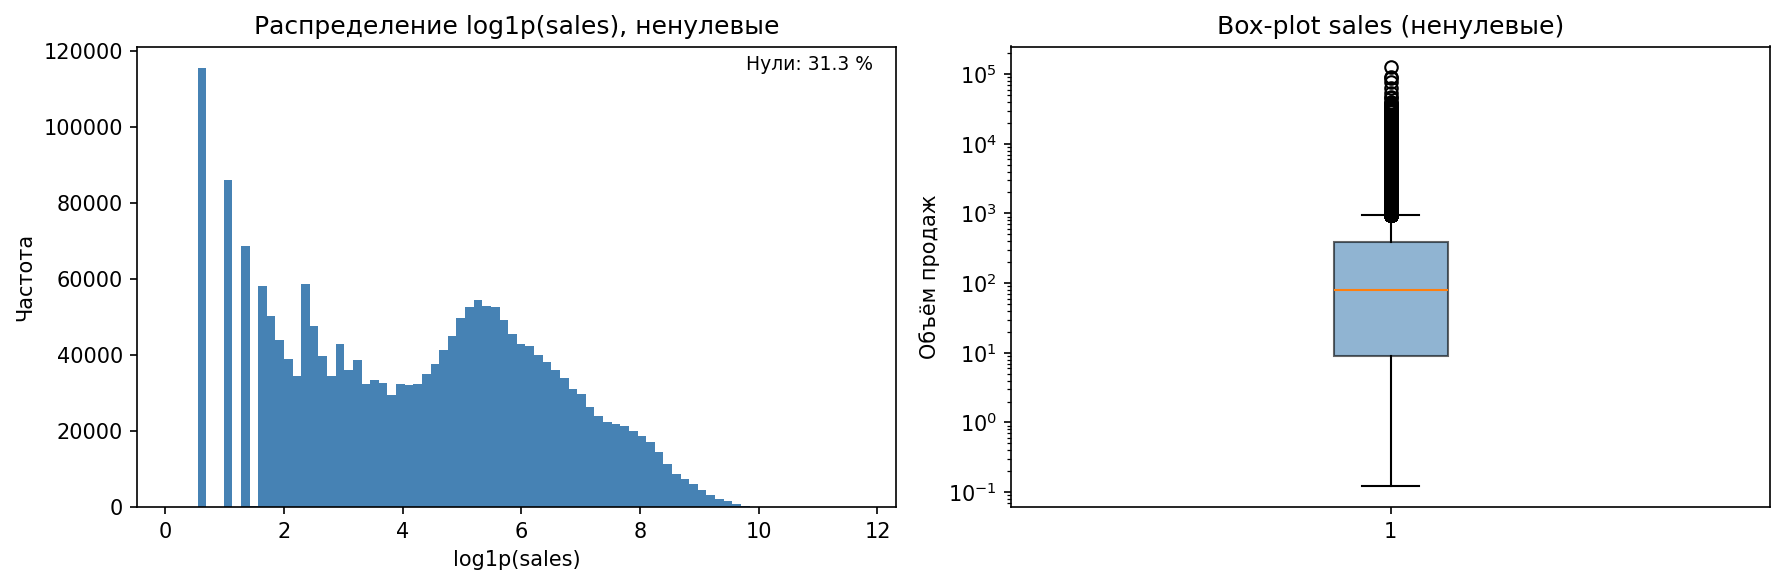

Сохранено: fig_sales_distribution.png


In [4]:
# ── Ячейка 3: Распределение sales → fig_sales_distribution.png ──────────────
train = data["train"]

zero_pct = (train["sales"] == 0).mean() * 100
print(f"Доля нулевых продаж: {zero_pct:.1f} %")
print(train["sales"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sales_nonzero = train.loc[train["sales"] > 0, "sales"]
axes[0].hist(np.log1p(sales_nonzero), bins=80, color="steelblue", edgecolor="none")
axes[0].set_title("Распределение log1p(sales), ненулевые")
axes[0].set_xlabel("log1p(sales)")
axes[0].set_ylabel("Частота")
axes[0].annotate(f"Нули: {zero_pct:.1f} %", xy=(0.97, 0.95),
                 xycoords="axes fraction", ha="right", fontsize=9)

axes[1].boxplot(sales_nonzero, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_title("Box-plot sales (ненулевые)")
axes[1].set_ylabel("Объём продаж")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig(FIGURES / "fig_sales_distribution.png", bbox_inches="tight")
plt.show()
print("Сохранено: fig_sales_distribution.png")

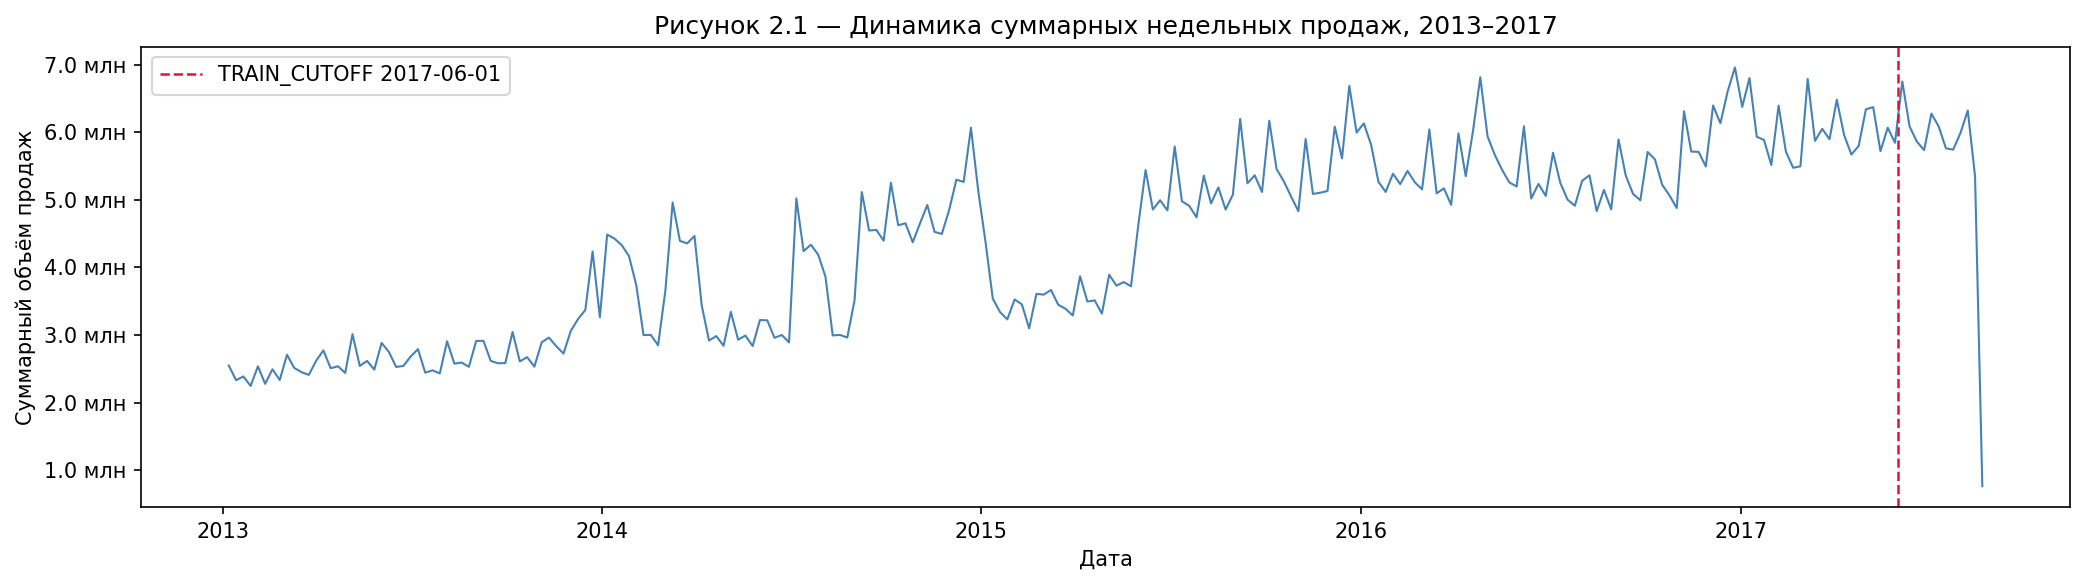

Сохранено: fig_weekly_sales_dynamics.png


In [5]:
# ── Ячейка 4: Динамика суммарных продаж 2013–2017 → fig_weekly_sales_dynamics.png
train_ts = train.copy()
train_ts[DATE_COL] = pd.to_datetime(train_ts[DATE_COL])

weekly_sales = (
    train_ts.groupby(DATE_COL)["sales"]
    .sum()
    .resample("W-MON")
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(weekly_sales.index, weekly_sales.values, color="steelblue", linewidth=1)
ax.axvline(pd.Timestamp(TRAIN_CUTOFF), color="crimson", linestyle="--",
           linewidth=1.2, label=f"TRAIN_CUTOFF {TRAIN_CUTOFF}")
ax.set_title("Рисунок 2.1 — Динамика суммарных недельных продаж, 2013–2017")
ax.set_xlabel("Дата")
ax.set_ylabel("Суммарный объём продаж")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f} млн"))
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "fig_weekly_sales_dynamics.png", bbox_inches="tight")
plt.show()
print("Сохранено: fig_weekly_sales_dynamics.png")

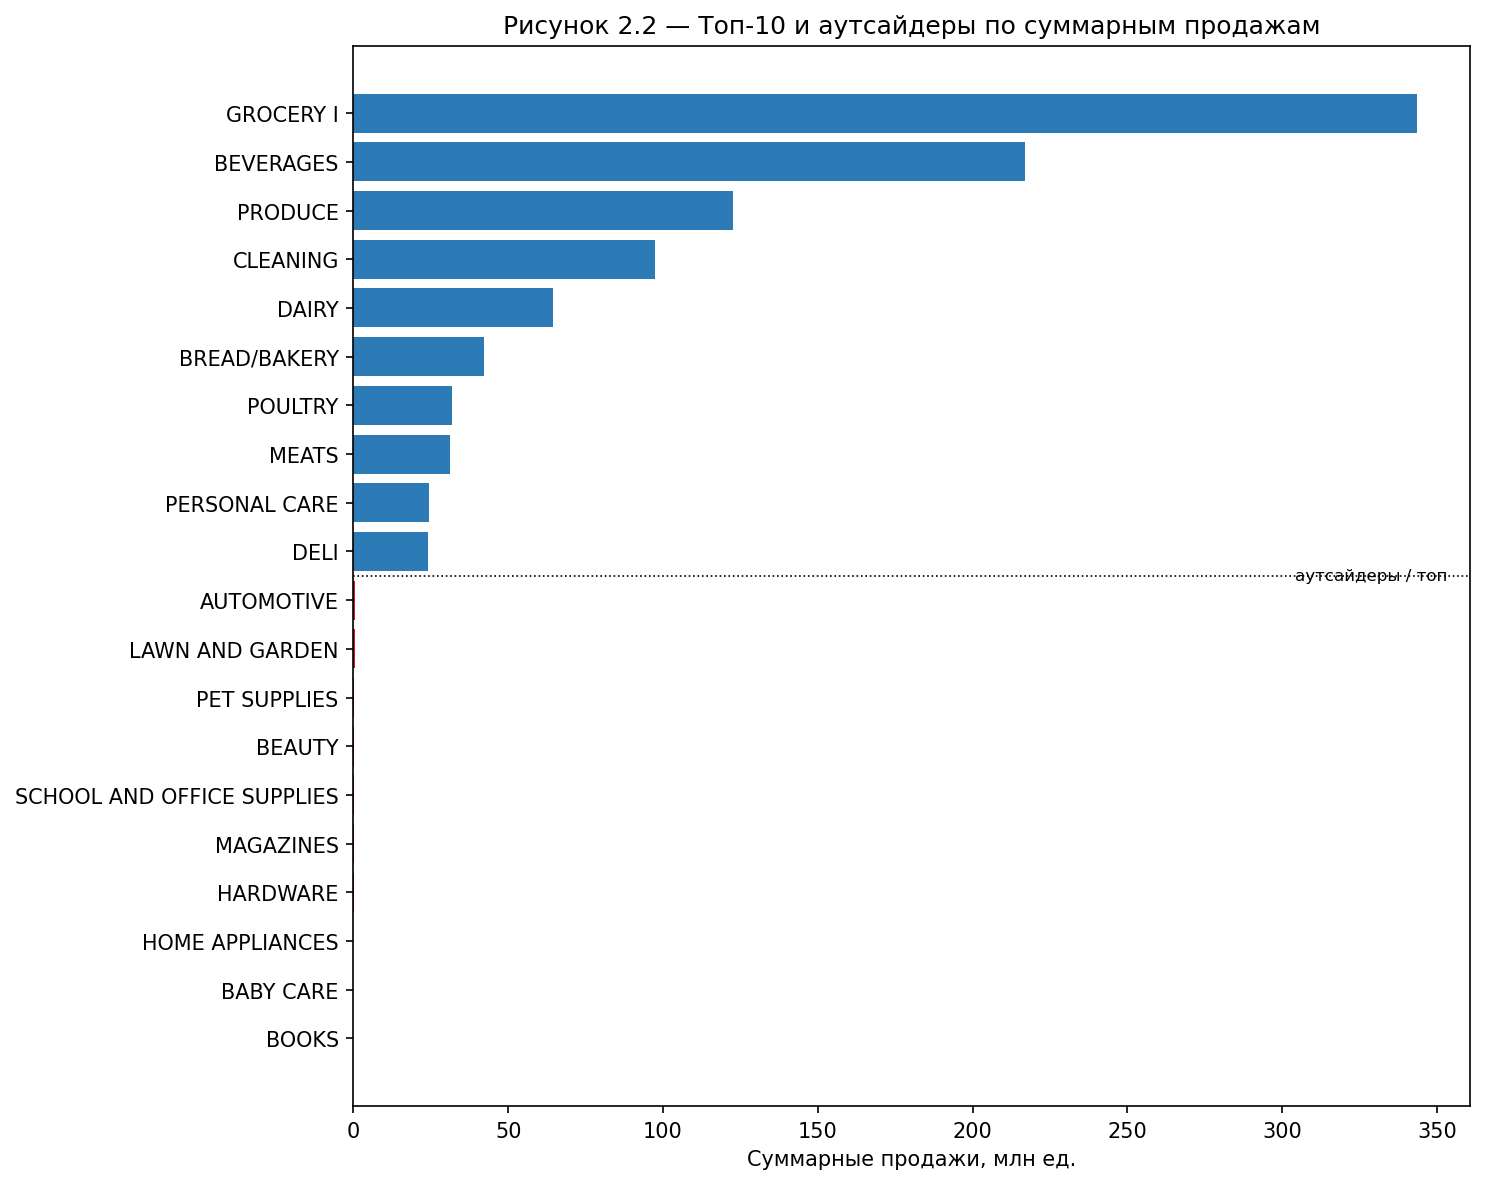

Сохранено: fig_family_sales_ranking.png


In [6]:
# ── Ячейка 5: Топ/аутсайдеры по семействам → fig_family_sales_ranking.png ───
family_totals = (
    train.groupby(FAMILY_COL)["sales"]
    .sum()
    .sort_values(ascending=True)
)

family_totals.to_frame("total_sales").to_csv(TABLES / "table_family_totals.csv")

top_n = 10
plot_data = pd.concat([family_totals.head(top_n), family_totals.tail(top_n)])

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#d7191c" if i < top_n else "#2c7bb6" for i in range(len(plot_data))]
ax.barh(plot_data.index, plot_data.values / 1e6, color=colors)
ax.axhline(top_n - 0.5, color="black", linestyle=":", linewidth=0.8)
ax.set_xlabel("Суммарные продажи, млн ед.")
ax.set_title("Рисунок 2.2 — Топ-10 и аутсайдеры по суммарным продажам")
ax.text(ax.get_xlim()[1] * 0.98, top_n - 0.5,
        "аутсайдеры / топ", ha="right", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / "fig_family_sales_ranking.png", bbox_inches="tight")
plt.show()
print("Сохранено: fig_family_sales_ranking.png")

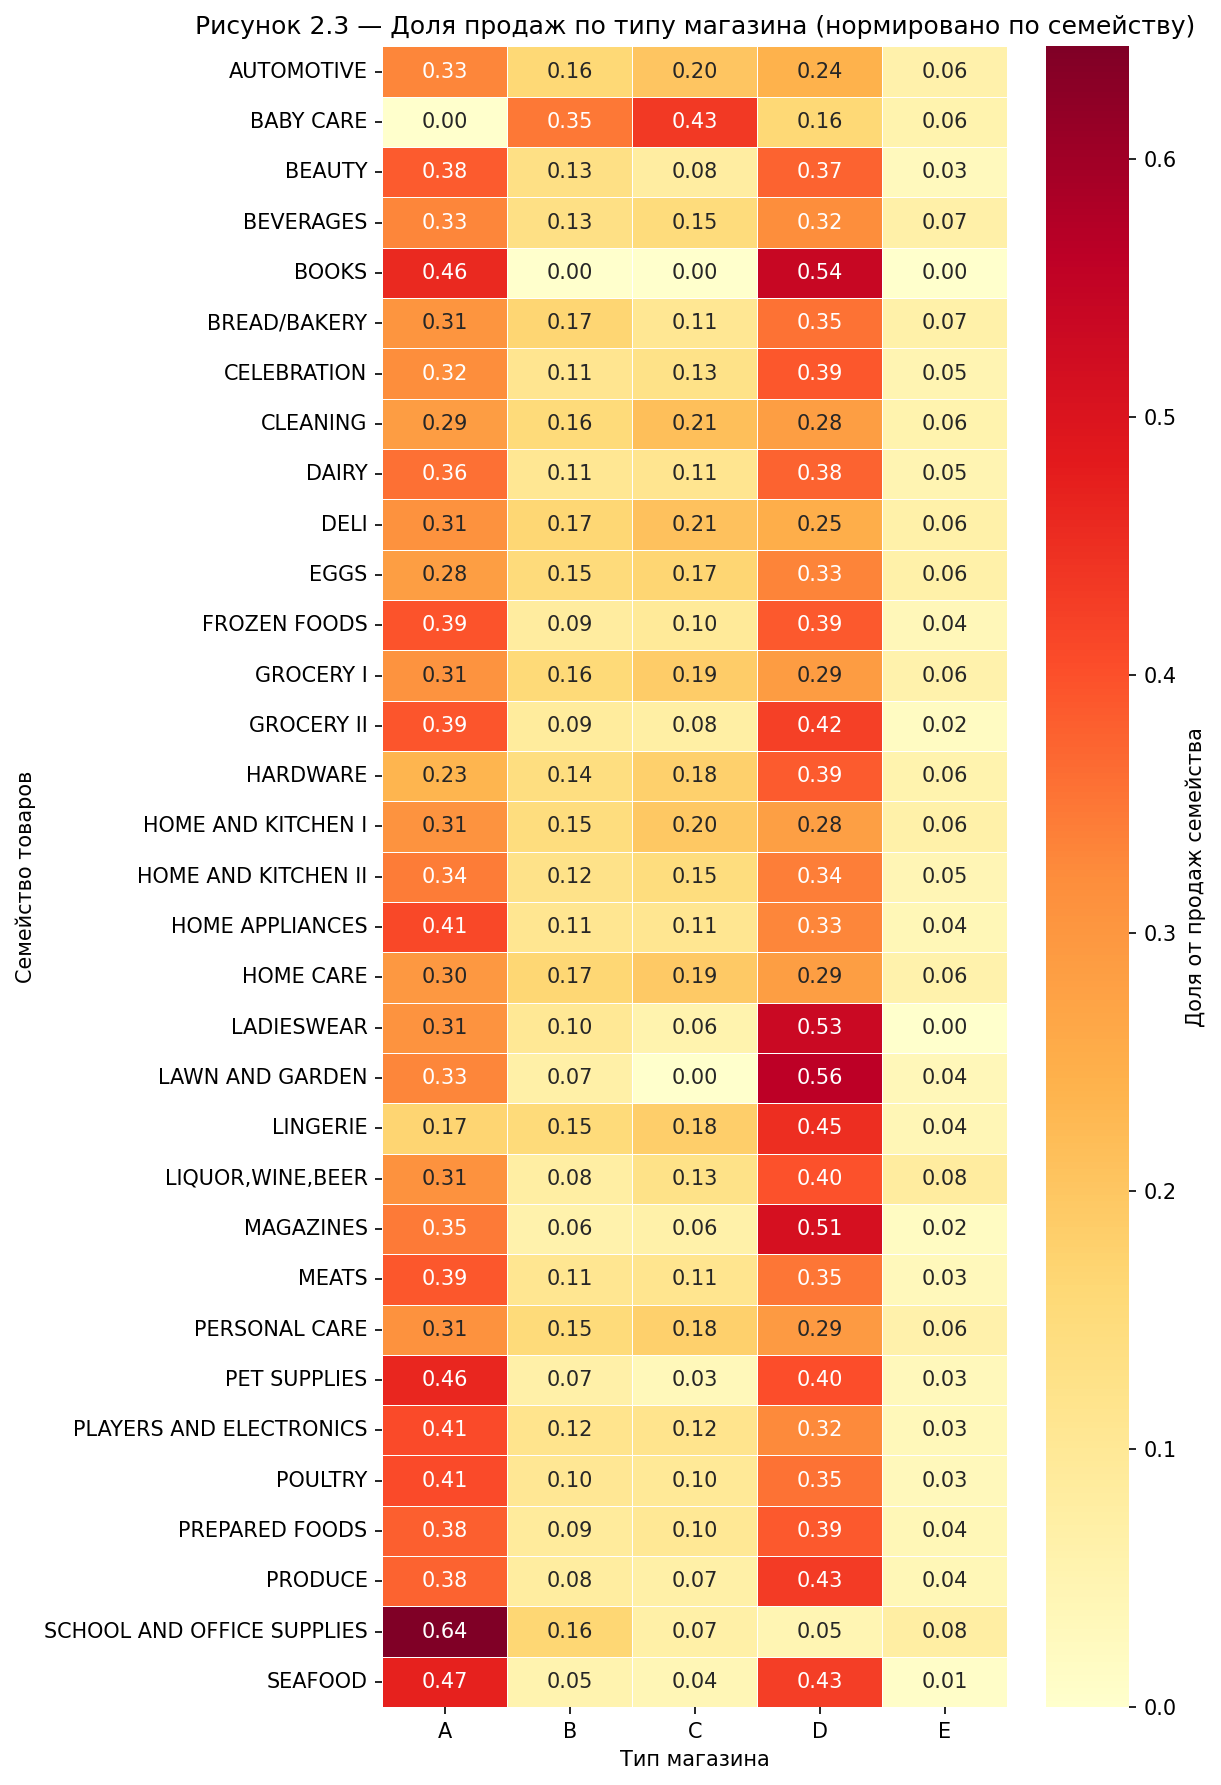

Сохранено: fig_heatmap_type_family.png


In [7]:
# ── Ячейка 6: Тепловая карта store_type × family → fig_heatmap_type_family.png
stores = data["stores"][[STORE_COL, "type"]].rename(columns={"type": "store_type"})
train_typed = train.merge(stores, on=STORE_COL, how="left")

pivot = (
    train_typed.groupby(["store_type", FAMILY_COL])["sales"]
    .sum()
    .unstack("store_type")
)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(
    pivot_norm, annot=True, fmt=".2f", cmap="YlOrRd",
    linewidths=0.3, ax=ax, cbar_kws={"label": "Доля от продаж семейства"}
)
ax.set_title("Рисунок 2.3 — Доля продаж по типу магазина (нормировано по семейству)")
ax.set_xlabel("Тип магазина")
ax.set_ylabel("Семейство товаров")
plt.tight_layout()
plt.savefig(FIGURES / "fig_heatmap_type_family.png", bbox_inches="tight")
plt.show()
print("Сохранено: fig_heatmap_type_family.png")

Корреляция Пирсона (sales_weekly, oil_price): -0.752


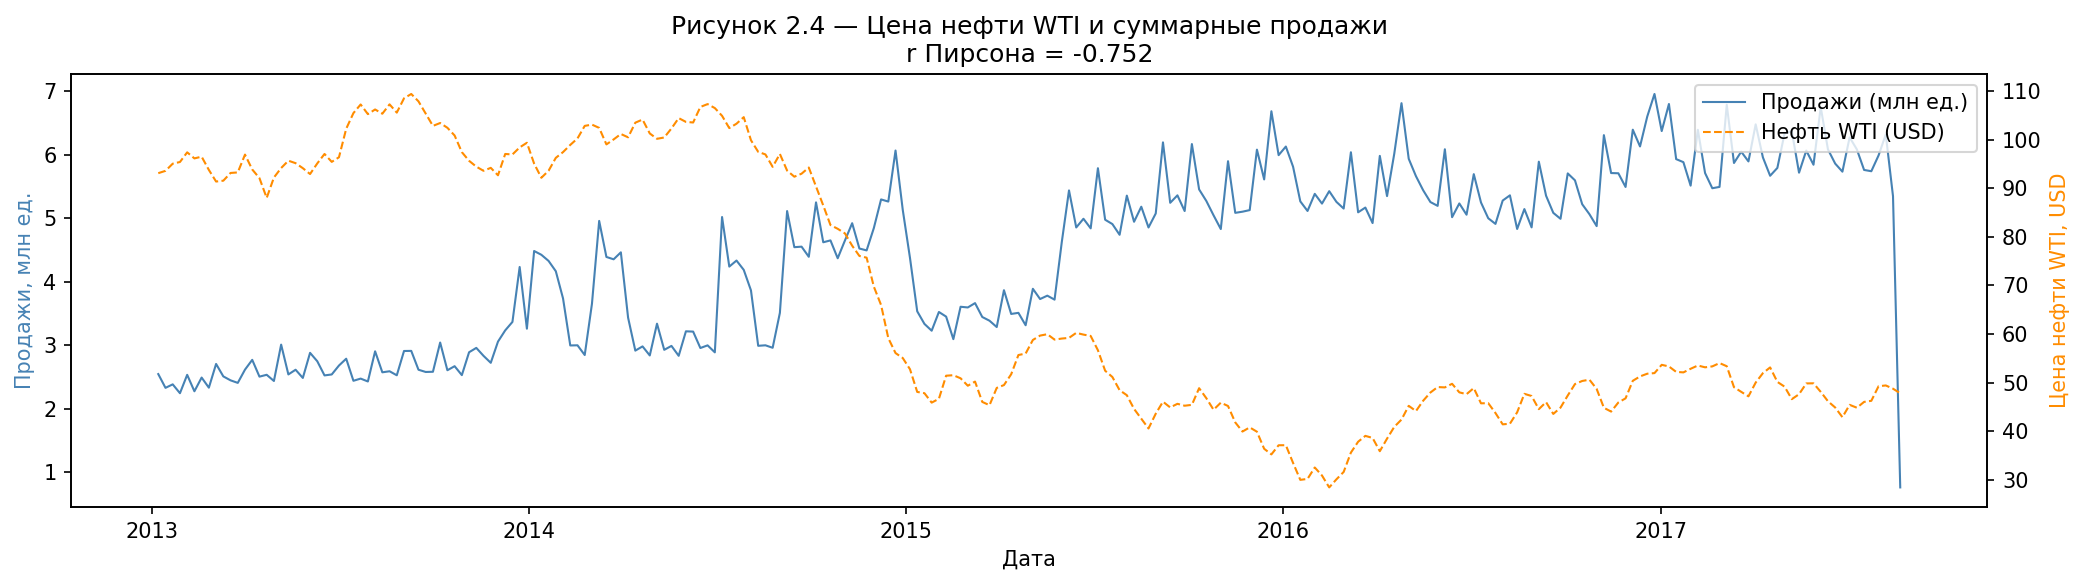

Сохранено: fig_oil_vs_sales.png


In [8]:
# ── Ячейка 7: Нефть vs продажи → fig_oil_vs_sales.png ──────────────────────
oil_filled = fill_oil_gaps(data["oil"])
oil_filled[DATE_COL] = pd.to_datetime(oil_filled[DATE_COL])

oil_weekly = (
    oil_filled.set_index(DATE_COL)["dcoilwtico"]
    .resample("W-MON")
    .mean()
)

combined = pd.DataFrame({
    "sales_weekly": weekly_sales,
    "oil_price": oil_weekly,
}).dropna()

corr = combined["sales_weekly"].corr(combined["oil_price"])
print(f"Корреляция Пирсона (sales_weekly, oil_price): {corr:.3f}")

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.plot(combined.index, combined["sales_weekly"] / 1e6,
         color="steelblue", linewidth=1, label="Продажи (млн ед.)")
ax2.plot(combined.index, combined["oil_price"],
         color="darkorange", linewidth=1, linestyle="--", label="Нефть WTI (USD)")
ax1.set_ylabel("Продажи, млн ед.", color="steelblue")
ax2.set_ylabel("Цена нефти WTI, USD", color="darkorange")
ax1.set_xlabel("Дата")
ax1.set_title(f"Рисунок 2.4 — Цена нефти WTI и суммарные продажи\nr Пирсона = {corr:.3f}")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.savefig(FIGURES / "fig_oil_vs_sales.png", bbox_inches="tight")
plt.show()
print("Сохранено: fig_oil_vs_sales.png")

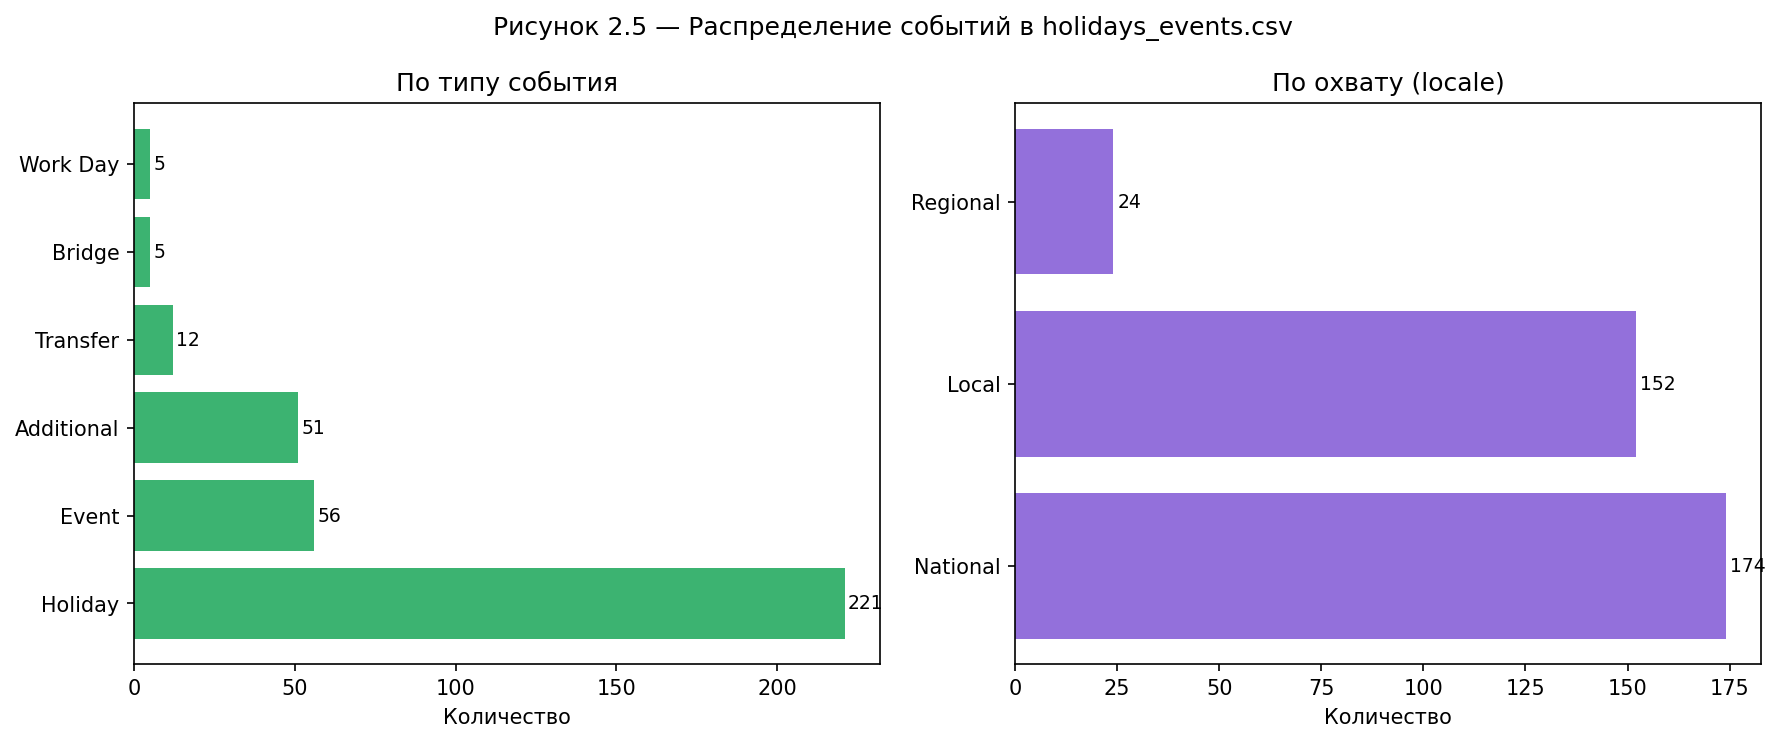


Признак transferred:
transferred
False    338
True      12
Name: count, dtype: int64

Сохранено: fig_holidays_by_type.png


In [9]:
# ── Ячейка 8: Праздники по типам и охвату → fig_holidays_by_type.png ────────
holidays = data["holidays"].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

type_counts = holidays["type"].value_counts()
axes[0].barh(type_counts.index, type_counts.values, color="mediumseagreen")
axes[0].set_title("По типу события")
axes[0].set_xlabel("Количество")
for i, v in enumerate(type_counts.values):
    axes[0].text(v + 1, i, str(v), va="center", fontsize=9)

locale_counts = holidays["locale"].value_counts()
axes[1].barh(locale_counts.index, locale_counts.values, color="mediumpurple")
axes[1].set_title("По охвату (locale)")
axes[1].set_xlabel("Количество")
for i, v in enumerate(locale_counts.values):
    axes[1].text(v + 1, i, str(v), va="center", fontsize=9)

fig.suptitle("Рисунок 2.5 — Распределение событий в holidays_events.csv")
plt.tight_layout()
plt.savefig(FIGURES / "fig_holidays_by_type.png", bbox_inches="tight")
plt.show()
print("\nПризнак transferred:")
print(holidays["transferred"].value_counts())
print("\nСохранено: fig_holidays_by_type.png")

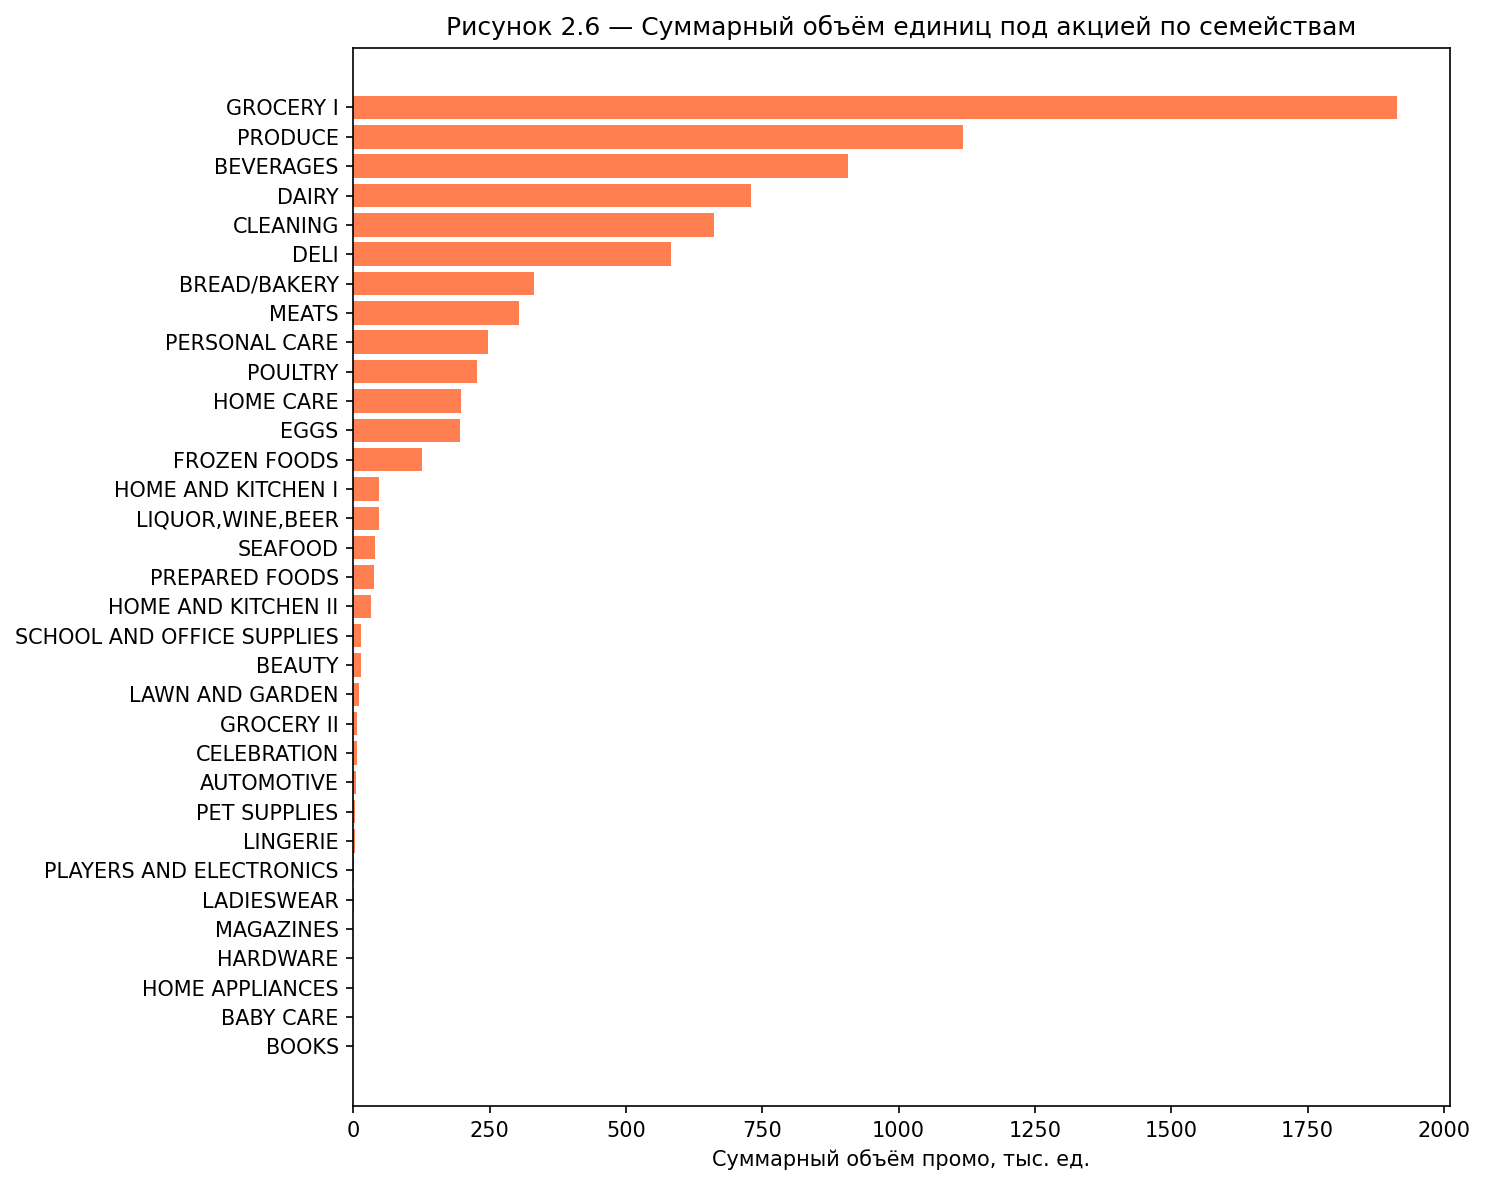

Сохранено: fig_promo_by_family.png


In [10]:
# ── Ячейка 9: Промо по семействам ──────────────────────────────────────────
promo_by_family = (
    train.groupby(FAMILY_COL)["onpromotion"]
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(promo_by_family.index, promo_by_family.values / 1e3, color="coral")
ax.set_xlabel("Суммарный объём промо, тыс. ед.")
ax.set_title("Рисунок 2.6 — Суммарный объём единиц под акцией по семействам")
plt.tight_layout()
plt.savefig(FIGURES / "fig_promo_by_family.png", bbox_inches="tight")
plt.show()
print("Сохранено: fig_promo_by_family.png")

Корреляция Пирсона (transactions_weekly, sales_weekly): 0.589


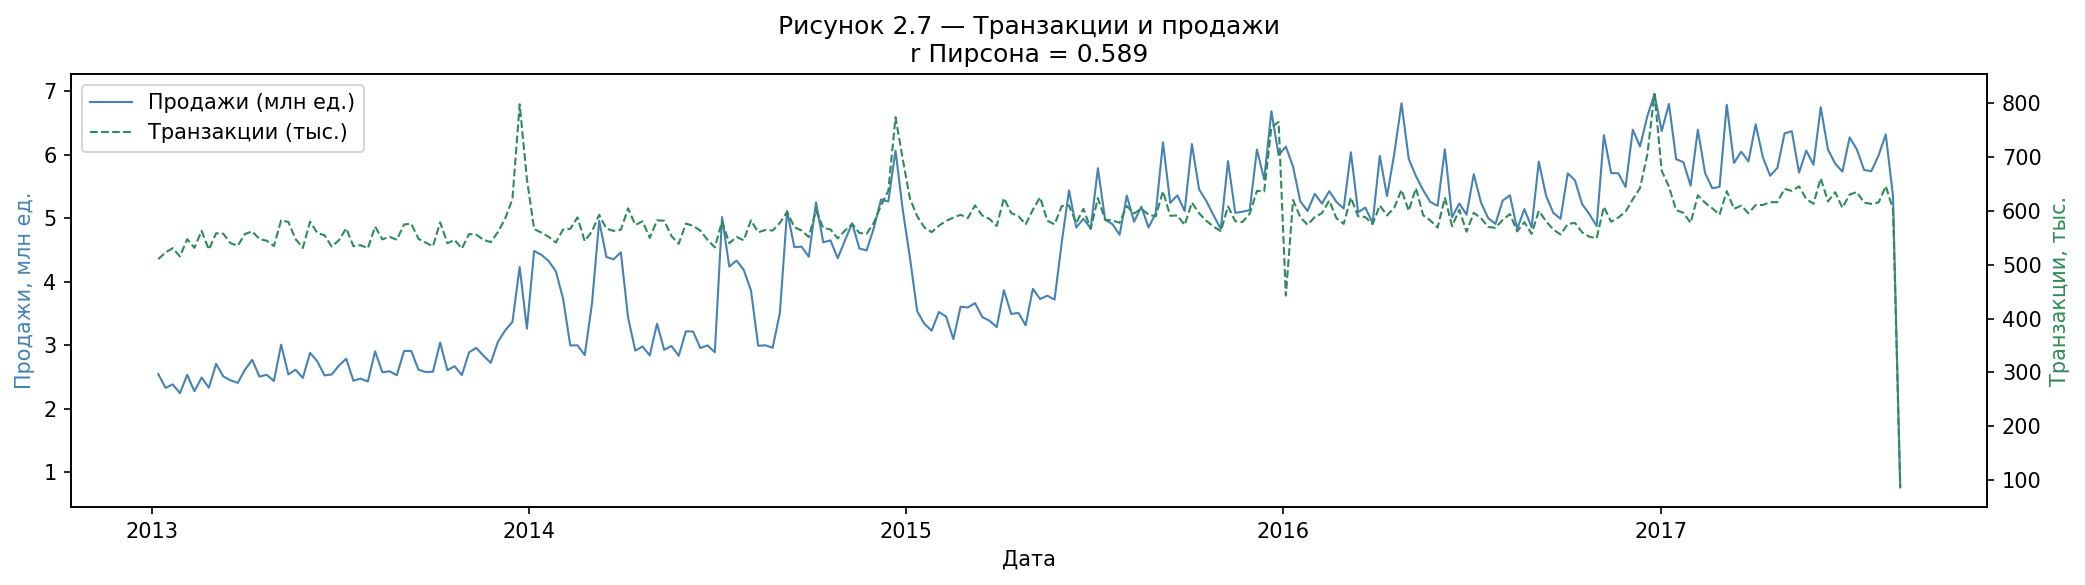

Сохранено: fig_transactions_vs_sales.png


In [11]:
# ── Ячейка 10: Транзакции — посещаемость магазинов ─────────────────────────
tx = data["transactions"].copy()
tx[DATE_COL] = pd.to_datetime(tx[DATE_COL])

tx_weekly = (
    tx.groupby(DATE_COL)["transactions"]
    .sum()
    .resample("W-MON")
    .sum()
)

tx_sales = pd.DataFrame({
    "transactions": tx_weekly,
    "sales": weekly_sales,
}).dropna()
corr_tx = tx_sales["transactions"].corr(tx_sales["sales"])
print(f"Корреляция Пирсона (transactions_weekly, sales_weekly): {corr_tx:.3f}")

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.plot(tx_sales.index, tx_sales["sales"] / 1e6,
         color="steelblue", linewidth=1, label="Продажи (млн ед.)")
ax2.plot(tx_sales.index, tx_sales["transactions"] / 1e3,
         color="seagreen", linewidth=1, linestyle="--", label="Транзакции (тыс.)")
ax1.set_ylabel("Продажи, млн ед.", color="steelblue")
ax2.set_ylabel("Транзакции, тыс.", color="seagreen")
ax1.set_xlabel("Дата")
ax1.set_title(f"Рисунок 2.7 — Транзакции и продажи\nr Пирсона = {corr_tx:.3f}")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES / "fig_transactions_vs_sales.png", bbox_inches="tight")
plt.show()
print("Сохранено: fig_transactions_vs_sales.png")

In [12]:
# ── Ячейка 11: Итоговый словарь ключевых чисел → table_eda_summary.csv ──────
summary = {
    "train_rows": len(train),
    "train_date_min": str(train[DATE_COL].min().date()),
    "train_date_max": str(train[DATE_COL].max().date()),
    "n_stores": int(train[STORE_COL].nunique()),
    "n_families": int(train[FAMILY_COL].nunique()),
    "zero_sales_pct": round(zero_pct, 2),
    "oil_missing_days_raw": int(data["oil"]["dcoilwtico"].isna().sum()),
    "corr_oil_sales": round(corr, 3),
    "corr_tx_sales": round(corr_tx, 3),
    "n_holidays_total": len(data["holidays"]),
    "n_holidays_transferred": int(data["holidays"]["transferred"].sum()),
}

summary_df = pd.DataFrame([summary]).T.rename(columns={0: "Значение"})
summary_df.to_csv(TABLES / "table_eda_summary.csv")
print("Таблица 2.2 — Ключевые показатели EDA")
display(summary_df)
print("\nНоутбук 00 выполнен. Артефакты сохранены в reports/")

Таблица 2.2 — Ключевые показатели EDA


,Значение
train_rows,3000888
train_date_min,2013-01-01
train_date_max,2017-08-15
n_stores,54
n_families,33
zero_sales_pct,31.3
oil_missing_days_raw,43
corr_oil_sales,-0.752
corr_tx_sales,0.589
n_holidays_total,350



Ноутбук 00 выполнен. Артефакты сохранены в reports/
